In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Settings
plt.style.use('dark_background')
COLORS = ['#00d4ff', '#ff007f', '#39ff14', '#ffd700']
LOG_FILE = "../evaluation/reports/training_log_20260329_155645.txt" # Using latest available

## 1. Parse Training Logs

In [6]:
def parse_logs(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            if 'Ep' in line and '|' in line:
                match = re.search(r"Ep\s+(\d+)\s+\|\s+Reward:\s+([\-\d\.]+)\s+\|\s+Steps:\s+([\d\.]+)\s+\|\s+Success:\s+([\d\.]+)%", line)
                if match:
                    ep = int(match.group(1))
                    reward = float(match.group(2))
                    steps = float(match.group(3))
                    success = float(match.group(4))
                    
                    # Extract strategy dist
                    dist = {}
                    for strat in ['ROUTE', 'CLARIFY', 'SUGGEST', 'ESCALATE']:
                        s_match = re.search(f"{strat}:\s+([\d\.]+)%", line)
                        dist[strat] = float(s_match.group(1)) if s_match else 0
                        
                    data.append({
                        "episode": ep,
                        "reward": reward,
                        "steps": steps,
                        "success_rate": success,
                        **dist
                    })
    return pd.DataFrame(data)

df_logs = parse_logs(LOG_FILE)
df_logs.head()

,episode,reward,steps,success_rate,ROUTE,CLARIFY,SUGGEST,ESCALATE
0,50,9.01,1.4,66.0,36.8,11.8,29.4,22.1
1,100,5.37,1.6,50.0,40.2,15.9,20.7,23.2
2,150,10.76,1.2,80.0,37.1,6.5,38.7,17.7
3,200,6.27,1.3,62.0,44.4,4.8,25.4,25.4
4,250,7.53,1.3,56.0,34.4,4.7,32.8,28.1


## 2. Reward & Success Curves

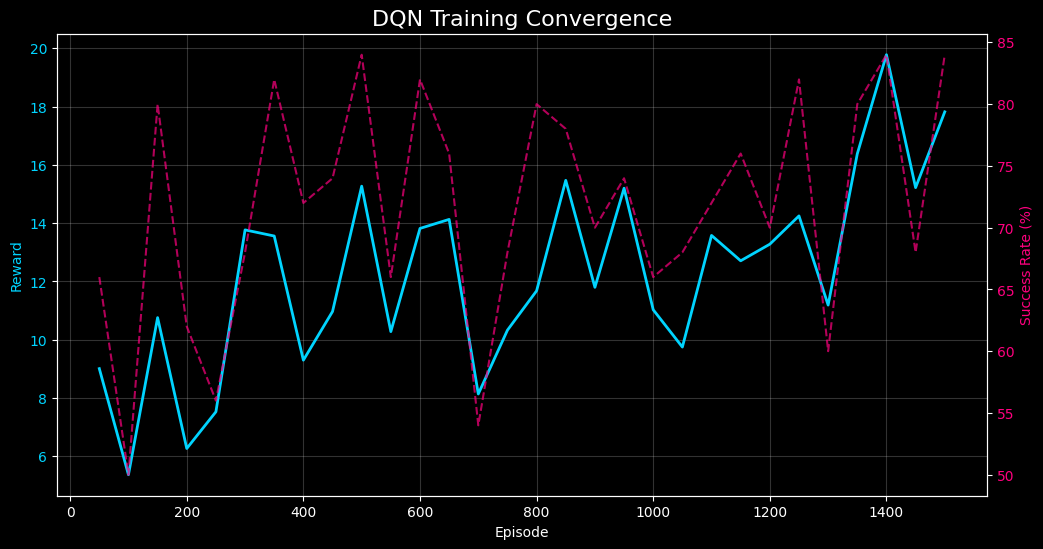

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward', color=COLORS[0])
ax1.plot(df_logs['episode'], df_logs['reward'], color=COLORS[0], linewidth=2, label='Avg Reward')
ax1.tick_params(axis='y', labelcolor=COLORS[0])
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
ax2.set_ylabel('Success Rate (%)', color=COLORS[1])
ax2.plot(df_logs['episode'], df_logs['success_rate'], color=COLORS[1], linestyle='--', alpha=0.7, label='Success Rate')
ax2.tick_params(axis='y', labelcolor=COLORS[1])

plt.title('DQN Training Convergence', fontsize=16)
plt.show()

## 3. Strategy Evolution

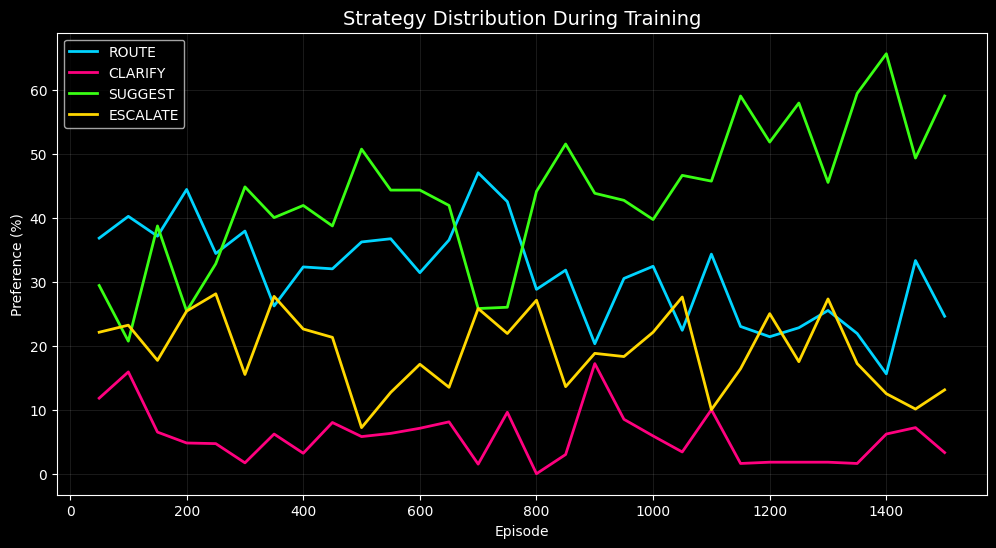

In [4]:
plt.figure(figsize=(12, 6))
strats = ['ROUTE', 'CLARIFY', 'SUGGEST', 'ESCALATE']
for i, s in enumerate(strats):
    plt.plot(df_logs['episode'], df_logs[s], label=s, color=COLORS[i % len(COLORS)], linewidth=2)

plt.title('Strategy Distribution During Training', fontsize=14)
plt.xlabel('Episode')
plt.ylabel('Preference (%)')
plt.legend()
plt.grid(alpha=0.1)
plt.show()